In [2]:
import sys

In [3]:
print (sys.executable)

/Users/juanmadendarys/Documents/project1/.venv/bin/python


In [47]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)


numpy: 2.4.1
pandas: 3.0.0
sklearn: 1.8.0


In [ ]:
SALARY_PATH_FILE = "../data/raw/salary.csv"
PEOPLE_PATH_FILE = "../data/raw/people.csv"
DESCRIPTIONS_PATH_FILE = "../data/raw/descriptions.csv"

df_salary = pd.read_csv(SALARY_PATH_FILE)
df_people = pd.read_csv(PEOPLE_PATH_FILE)
df_descriptions = pd.read_csv(DESCRIPTIONS_PATH_FILE)

Dataset: Salary

In [17]:
df_salary.head()

,id,Salary
0,0,90000.0
1,1,65000.0
2,2,150000.0
3,3,60000.0
4,4,200000.0


In [18]:
df_salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      375 non-null    int64  
 1   Salary  373 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 6.0 KB


In [19]:
df_salary.shape

(375, 2)

Dataset: People

In [20]:
df_people.head()

,id,Age,Gender,Education Level,Job Title,Years of Experience
0,0,32.0,Male,Bachelor's,Software Engineer,5.0
1,1,28.0,Female,Master's,Data Analyst,3.0
2,2,45.0,Male,PhD,Senior Manager,15.0
3,3,36.0,Female,Bachelor's,Sales Associate,7.0
4,4,52.0,Male,Master's,Director,20.0


In [21]:
df_people.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   375 non-null    int64  
 1   Age                  370 non-null    float64
 2   Gender               370 non-null    str    
 3   Education Level      370 non-null    str    
 4   Job Title            370 non-null    str    
 5   Years of Experience  373 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 17.7 KB


In [22]:
df_people.shape

(375, 6)

Dataset: Descriptions

In [23]:
df_descriptions.head()

,id,Description
0,0,I am a 32-year-old male working as a Software ...
1,1,I am a 28-year-old data analyst with a Master'...
2,2,I am a 45-year-old Senior Manager with a PhD a...
3,3,I am a 36-year-old female Sales Associate with...
4,4,I am a 52-year-old male with over two decades ...


In [24]:
df_descriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           375 non-null    int64
 1   Description  372 non-null    str  
dtypes: int64(1), str(1)
memory usage: 6.0 KB


In [25]:
df_descriptions.shape

(375, 2)

- df_salary: contains salary information per person
- df_people: contains demographic and professional information
- df_descriptions: contains job-related descriptions.

In [26]:
df_salary["id"].nunique(), df_salary.shape[0]

(375, 375)

In [27]:
df_people["id"].nunique(), df_people.shape[0]


(375, 375)

In [28]:
df_descriptions["id"].nunique(), df_descriptions.shape[0]


(375, 375)

In [29]:
set(df_salary["id"]) == set(df_people["id"])

True

In [30]:
set(df_salary["id"]) == set(df_descriptions["id"])


True

In [33]:
df_descriptions["Description"].str.len().describe()

count    372.000000
mean     635.303763
std       66.083029
min      301.000000
25%      605.250000
50%      646.000000
75%      674.000000
max      975.000000
Name: Description, dtype: float64

In [34]:
df_model = df_salary.merge(
    df_people,
    on="id",
    how="inner"
)

In [35]:
df_model.shape

(375, 7)

In [36]:
df_model.isna().sum()

id                     0
Salary                 2
Age                    5
Gender                 5
Education Level        5
Job Title              5
Years of Experience    2
dtype: int64

In [39]:
print(df_salary["id"].nunique(), df_salary.shape[0])
print(df_people["id"].nunique(), df_people.shape[0])
df_descriptions["id"].nunique(), df_descriptions.shape[0]


375 375
375 375


(375, 375)

## About textual descriptions

The dataset includes a free-text field describing each person's professional background.
While this information could potentially be used through NLP techniques, it was not included
in the initial baseline model.

The first modeling approach focuses on structured variables (demographic and professional),
which allows for a clearer interpretation of feature impact and reduces the risk of overfitting
given the dataset size. Text-based features are considered as a possible extension.


In [40]:
target = "Salary"


In [41]:
df_model[target].describe()

count       373.000000
mean     100577.345845
std       48240.013482
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

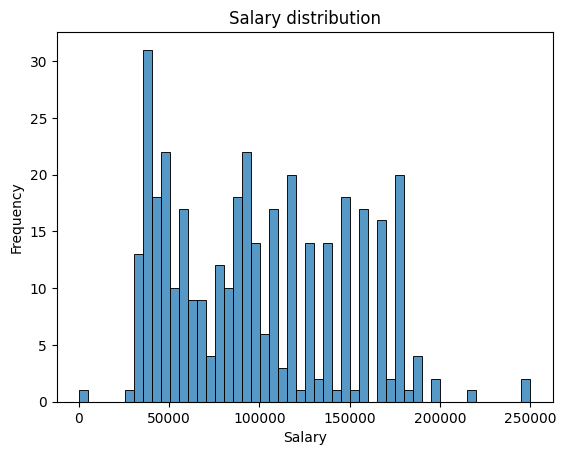

In [48]:
sns.histplot(df_model[target], bins=50)
plt.title("Salary distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()


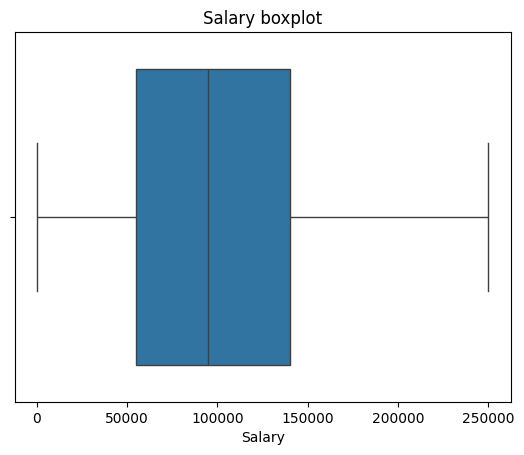

In [49]:
sns.boxplot(x=df_model[target])
plt.title("Salary boxplot")
plt.show()


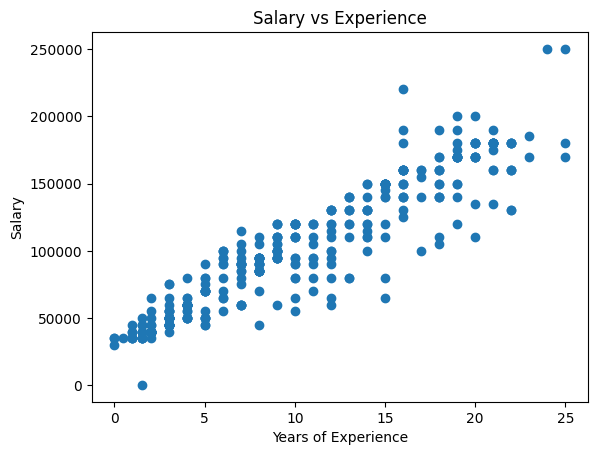

In [53]:
plt.scatter(df_model["Years of Experience"], df_model["Salary"])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.show()

## Salary vs Years of Experience

The scatter plot shows a clear positive relationship between years of experience and salary,
which is consistent with domain expectations. Most observations follow a coherent upward trend.

The visualization also helps identify outliers in context. A single observation with a very low
salary stands far below the general pattern, suggesting a potential data quality issue.
In contrast, a small number of high-salary observations appear at higher experience levels and
remain consistent with the overall trend, indicating that they may represent valid extreme cases.


In [54]:
df_model_clean = df_model.dropna(subset=["Salary"])


In [55]:
X = df_model_clean.drop(columns=["Salary"])
y = df_model_clean["Salary"]


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [57]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)


,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'median'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None


In [58]:
y_pred = dummy.predict(X_test)


In [59]:
from sklearn.metrics import mean_absolute_error

mae_baseline = mean_absolute_error(y_test, y_pred)
mae_baseline


40533.333333333336

In [60]:
X = df_model_clean.drop(columns=["Salary"])
y = df_model_clean["Salary"]

X_num = X.select_dtypes(include=["int64", "float64"])


In [61]:
X_num.columns


Index(['id', 'Age', 'Years of Experience'], dtype='str')

In [62]:
X_num.dtypes


id                       int64
Age                    float64
Years of Experience    float64
dtype: object

In [63]:
df_model_clean["Education Level"].unique()


<StringArray>
['Bachelor's', 'Master's', 'PhD', nan]
Length: 4, dtype: str

In [64]:
df_model_clean["Gender"].value_counts() , 


Gender
Male      193
Female    177
Name: count, dtype: int64

In [79]:
df_model_clean.shape, df_model_clean["Salary"].isna().sum()


((373, 7), np.int64(0))

In [80]:

df_model_clean["Age"] = pd.to_numeric(df_model_clean["Age"], errors="coerce")
df_model_clean["Years of Experience"] = pd.to_numeric(df_model_clean["Years of Experience"], errors="coerce")


In [82]:
cols = ["Age", "Years of Experience", "Gender", "Education Level"]
df_model_clean[cols].isna().sum()

Age                    3
Years of Experience    0
Gender                 0
Education Level        0
dtype: int64

In [83]:
age_median = df_model_clean["Age"].median()
exp_median = df_model_clean["Years of Experience"].median()

df_model_clean["Age"] = df_model_clean["Age"].fillna(age_median)
df_model_clean["Years of Experience"] = df_model_clean["Years of Experience"].fillna(exp_median)

df_model_clean["Gender"] = df_model_clean["Gender"].fillna("Unknown")
df_model_clean["Education Level"] = df_model_clean["Education Level"].fillna("Unknown")


In [84]:
df_model_clean[cols].isna().sum(), df_model_clean[cols].dtypes


(Age                    0
 Years of Experience    0
 Gender                 0
 Education Level        0
 dtype: int64,
 Age                    float64
 Years of Experience    float64
 Gender                     str
 Education Level            str
 dtype: object)

In [85]:
X = df_model_clean[["Age", "Years of Experience", "Gender", "Education Level"]]
y = df_model_clean["Salary"]


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

education_order = ["Unknown", "Bachelor's", "Master's", "PhD"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", ["Age", "Years of Experience"]),
        ("gender", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Gender"]),
        ("education", OrdinalEncoder(categories=[education_order], handle_unknown="use_encoded_value", unknown_value=-1), ["Education Level"]),
    ],
    remainder="drop"
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("regression", LinearRegression())
    ]
)


In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae_encoded = mean_absolute_error(y_test, y_pred)
mae_encoded


10574.237447453728

### Model performance

The linear regression model with numerical and encoded categorical features
achieved a Mean Absolute Error of approximately 10,600.

This represents a substantial improvement over the baseline model (MAE ≈ 40,500),
indicating that education level, experience, and gender contain strong predictive
signal for salary estimation.


In [90]:
df_model_clean["Education Level"].value_counts(dropna=False)


Education Level
Bachelor's    222
Master's       97
PhD            51
Unknown         3
Name: count, dtype: int64

In [91]:
df_model_clean["Job Title"].value_counts(dropna=False)


Job Title
Director of Marketing            12
Senior Business Analyst          10
Director of Operations           10
Senior Marketing Manager          9
Senior Marketing Analyst          9
                                 ..
Junior Research Scientist         1
Senior HR Specialist              1
Junior Operations Coordinator     1
Director of HR                    1
Junior Financial Advisor          1
Name: count, Length: 174, dtype: int64